# Traffic Jam_ Predicting People_s Movement into Nairobi

## Import Libraries

In [200]:
# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# Calendar (Holidays)
!pip install holidays
import holidays

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding and Scaling
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Data Splitting and Hyperparameter Tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV

# Modeling
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# Model Evaluation
from sklearn.metrics import r2_score, mean_absolute_error

# Model Saving
import joblib


## Loading Mobiticket Bookings Dataset

In [202]:

df=pd.read_csv(r"C:\Users\ADMIN\Desktop\unzipped\PROJECTS\Traffic Jam_ Predicting People_s Movement into Nairobi\Traffic Jam Predicting People_s Movement into Nairobi\Traffic Jam Predicting People's Movement into Nairobi\train_revised.csv")

In [203]:
df.head(5)

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,7:15,Migori,Nairobi,Bus,49
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,7:12,Migori,Nairobi,Bus,49
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,7:05,Keroka,Nairobi,Bus,49
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,7:10,Homa Bay,Nairobi,Bus,49
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,7:12,Migori,Nairobi,Bus,49


## Data preprocessing or data cleaning.

### Add column for passenger count per ride to analyze demand

In [206]:
# Count number of tickets booked per ride
count_of_tickets=df.ride_id.value_counts()
count_of_tickets

ride_id
8454     50
13211    49
10834    49
8090     49
11382    49
         ..
10090     1
10091     1
10114     1
10116     1
14304     1
Name: count, Length: 6249, dtype: int64

In [207]:
# Map ticket counts to each ride to create 'Number_of_tickets' column
df1=df.copy()
df1['Number_of_tickets']=df1.ride_id.map(count_of_tickets)

In [208]:
df1.head(6)

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,Number_of_tickets
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,7:15,Migori,Nairobi,Bus,49,1
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,7:12,Migori,Nairobi,Bus,49,1
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,7:05,Keroka,Nairobi,Bus,49,1
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,7:10,Homa Bay,Nairobi,Bus,49,5
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,7:12,Migori,Nairobi,Bus,49,31
5,5777,18B,Mpesa,B6PBDU30IZ,27-11-17,7:10,Homa Bay,Nairobi,Bus,49,5


In [209]:
df1.shape

(51645, 11)

##### # Remove personal client details and payment info to protect confidentiality and retain only analysis-relevant ride data


In [211]:
df2=df1.copy()
df2=df2.drop(['seat_number', 'payment_method', 'payment_receipt'],axis=1)
df2.head()


,ride_id,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,Number_of_tickets
0,1442,17-10-17,7:15,Migori,Nairobi,Bus,49,1
1,5437,19-11-17,7:12,Migori,Nairobi,Bus,49,1
2,5710,26-11-17,7:05,Keroka,Nairobi,Bus,49,1
3,5777,27-11-17,7:10,Homa Bay,Nairobi,Bus,49,5
4,5778,27-11-17,7:12,Migori,Nairobi,Bus,49,31


In [212]:
# # Remove duplicate rows to ensure data accuracy, prevent bias, and keep each ride unique

df3=df2.copy()
df3.duplicated().sum()

45396

In [213]:
df4=df3.drop_duplicates()
df4.shape

(6249, 8)

#### Check if any ride has more tickets booked than the vehicle's capacity

In [215]:
df4['Number_of_tickets'].unique()

array([ 1,  5, 31, 26,  2,  3, 11,  4,  9,  6,  8, 10, 24,  7, 22, 15, 17,
       25, 12, 27, 21, 23, 33, 19, 16, 28, 36, 13, 30, 41, 14, 18, 32, 20,
       40, 35, 37, 44, 45, 38, 29, 39, 34, 43, 48, 49, 47, 42, 50, 46],
      dtype=int64)

In [216]:
df4.describe()

,ride_id,max_capacity,Number_of_tickets
count,6249.000000,6249.000000,6249.000000
mean,9963.644583,30.392223,8.264522
std,2296.304872,18.997471,8.632968
min,1442.000000,11.000000,1.000000
25%,7989.000000,11.000000,2.000000
50%,10024.000000,49.000000,7.000000
75%,11917.000000,49.000000,11.000000
max,20117.000000,49.000000,50.000000


In [217]:
# Count rides where max capacity is 11 but tickets booked exceed 11
len(df4[(df4['max_capacity']==11)&(df4['Number_of_tickets']>11)])

12

In [218]:
# Keep rows where ticket count does not exceed a max capacity of 11
df5 = df4[~((df4['max_capacity'] == 11) & (df4['Number_of_tickets'] > 11))]
df5.shape

(6237, 8)

In [219]:
# Count rides where max capacity is 49 but tickets booked exceed 49
len(df5[(df5['max_capacity']==49)&(df5['Number_of_tickets']>49)])

1

In [220]:
df6 = df5[~((df5['max_capacity'] == 49) & (df5['Number_of_tickets'] > 49))]
df6.shape

(6236, 8)

In [221]:
# Check for missing (null) values in the dataset
df6.isnull().sum()

ride_id              0
travel_date          0
travel_time          0
travel_from          0
travel_to            0
car_type             0
max_capacity         0
Number_of_tickets    0
dtype: int64

In [222]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6236 entries, 0 to 51644
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ride_id            6236 non-null   int64 
 1   travel_date        6236 non-null   object
 2   travel_time        6236 non-null   object
 3   travel_from        6236 non-null   object
 4   travel_to          6236 non-null   object
 5   car_type           6236 non-null   object
 6   max_capacity       6236 non-null   int64 
 7   Number_of_tickets  6236 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 438.5+ KB


### Add new columns to extract time-based features for analyzing ride patterns


In [224]:
# Convert 'travel_date' and 'travel_time' columns to proper datetime and time data types

df7=df6.copy()
df7['travel_date']=pd.to_datetime(df7['travel_date'])
df7['travel_time']=pd.to_datetime(df7['travel_time'],format='%H:%M')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8852\1792069487.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df7['travel_date']=pd.to_datetime(df7['travel_date'])


In [225]:
df7.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6236 entries, 0 to 51644
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ride_id            6236 non-null   int64         
 1   travel_date        6236 non-null   datetime64[ns]
 2   travel_time        6236 non-null   datetime64[ns]
 3   travel_from        6236 non-null   object        
 4   travel_to          6236 non-null   object        
 5   car_type           6236 non-null   object        
 6   max_capacity       6236 non-null   int64         
 7   Number_of_tickets  6236 non-null   int64         
dtypes: datetime64[ns](2), int64(3), object(3)
memory usage: 438.5+ KB


In [226]:
# Extract day of week, month, and year from 'travel_date' and hours, minutes from 'travel_time'

df7['Years']=df7['travel_date'].dt.year
df7['Months']=df7['travel_date'].dt.month
df7['day_of_week']=df7['travel_date'].dt.dayofweek+1


df7['hours']=df7['travel_time'].dt.hour
df7['minutes']=df7['travel_time'].dt.minute


In [227]:
df7.head()

,ride_id,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,Number_of_tickets,Years,Months,day_of_week,hours,minutes
0,1442,2017-10-17,1900-01-01 07:15:00,Migori,Nairobi,Bus,49,1,2017,10,2,7,15
1,5437,2017-11-19,1900-01-01 07:12:00,Migori,Nairobi,Bus,49,1,2017,11,7,7,12
2,5710,2017-11-26,1900-01-01 07:05:00,Keroka,Nairobi,Bus,49,1,2017,11,7,7,5
3,5777,2017-11-27,1900-01-01 07:10:00,Homa Bay,Nairobi,Bus,49,5,2017,11,1,7,10
4,5778,2017-11-27,1900-01-01 07:12:00,Migori,Nairobi,Bus,49,31,2017,11,1,7,12


In [228]:
# Validate extracted features to ensure no invalid months, days of week, hours, or minutes
df7.describe()

,ride_id,travel_date,travel_time,max_capacity,Number_of_tickets,Years,Months,day_of_week,hours,minutes
count,6236.000000,6236,6236,6236.000000,6236.000000,6236.000000,6236.000000,6236.000000,6236.000000,6236.000000
mean,9963.760263,2018-03-03 09:21:07.735727872,1900-01-01 08:14:16.587555840,30.426555,8.250641,2017.738133,5.759140,3.915651,7.947402,17.432328
min,1442.000000,2017-01-12 00:00:00,1900-01-01 05:00:00,11.000000,1.000000,2017.000000,1.000000,1.000000,5.000000,0.000000
25%,7985.750000,2017-12-28 18:00:00,1900-01-01 07:04:00,11.000000,2.000000,2017.000000,2.000000,2.000000,7.000000,5.000000
50%,10024.500000,2018-02-21 00:00:00,1900-01-01 07:10:00,49.000000,7.000000,2018.000000,4.000000,4.000000,7.000000,10.000000
75%,11919.250000,2018-04-17 00:00:00,1900-01-01 08:40:00,49.000000,11.000000,2018.000000,10.000000,6.000000,8.000000,30.000000
max,20117.000000,2018-12-04 00:00:00,1900-01-01 23:10:00,49.000000,49.000000,2018.000000,12.000000,7.000000,23.000000,59.000000
std,2297.704057,NaN,NaN,18.996734,8.624216,0.439686,4.076538,1.958660,2.949420,17.008137


#### Add 'is_holiday' column to identify whether a ride occurred on a holiday for better demand analysis

In [230]:
df8=df7.copy()
# Kenya holidays for 2017 and 2018
ke_holidays = holidays.Kenya(years=[2017, 2018])

# Create 'is_holiday' column with 'Yes' or 'No' values
df8['is_holiday'] = df8['travel_date'].isin(ke_holidays).map({True: 'Yes', False: 'No'})


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8852\3476743331.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df8['is_holiday'] = df8['travel_date'].isin(ke_holidays).map({True: 'Yes', False: 'No'})


In [231]:
df8.head()

,ride_id,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,Number_of_tickets,Years,Months,day_of_week,hours,minutes,is_holiday
0,1442,2017-10-17,1900-01-01 07:15:00,Migori,Nairobi,Bus,49,1,2017,10,2,7,15,No
1,5437,2017-11-19,1900-01-01 07:12:00,Migori,Nairobi,Bus,49,1,2017,11,7,7,12,No
2,5710,2017-11-26,1900-01-01 07:05:00,Keroka,Nairobi,Bus,49,1,2017,11,7,7,5,No
3,5777,2017-11-27,1900-01-01 07:10:00,Homa Bay,Nairobi,Bus,49,5,2017,11,1,7,10,No
4,5778,2017-11-27,1900-01-01 07:12:00,Migori,Nairobi,Bus,49,31,2017,11,1,7,12,No


In [232]:
len(df8[df8['is_holiday']=='Yes'])

254

 - There are 254 rides that took place on holidays
 - This helps us analyze how holidays affect ride demand, enabling better scheduling, resource allocation, and demand forecasting

In [234]:
# Ocurring Holidays
# Get the unique travel dates
unique_dates = df8['travel_date'].unique()

# Find which of these dates are holidays
holiday_dates_in_data = [d for d in unique_dates if d in ke_holidays]

# Convert to DataFrame for easier viewing if you want
holiday_df = pd.DataFrame({
    'holiday_date': holiday_dates_in_data,
    'holiday_name': [ke_holidays[d] for d in holiday_dates_in_data]
})

# Sort holidays in the dataset by date
holiday_df = holiday_df.sort_values(by='holiday_date').reset_index(drop=True)
display(holiday_df)

,holiday_date,holiday_name
0,2017-11-28,Inauguration Day
1,2017-12-12,Jamhuri Day
2,2017-12-25,Christmas Day
3,2017-12-26,Boxing Day
4,2018-01-01,New Year's Day
5,2018-03-30,Good Friday
6,2018-04-02,Easter Monday
7,2018-05-01,Labour Day
8,2018-06-01,Madaraka Day


##  Exploratory Data Analysis (EDA) – Visual Insights

In [ ]:
# Regions and the numbers of pasengers that ravelled to the  city

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8852\2811990781.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


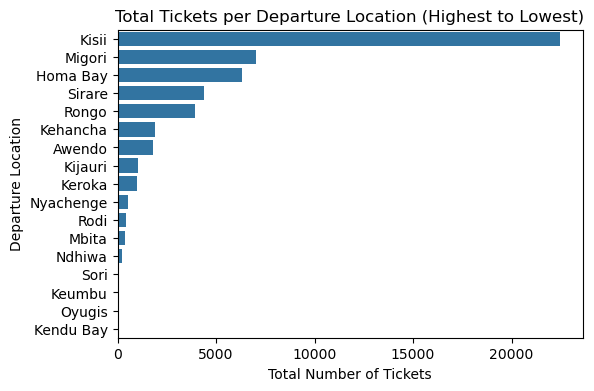

In [501]:
# Aggregate total tickets per departure location
df_sorted = df8.groupby('travel_from')['Number_of_tickets'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(6,4))
sns.barplot(
    data=df_sorted,
    y='travel_from',
    x='Number_of_tickets',
    ci=None
)
plt.title("Total Tickets per Departure Location (Highest to Lowest)")
plt.xlabel("Total Number of Tickets")
plt.ylabel("Departure Location")
plt.show()

In [503]:
df_sorted


,travel_from,Number_of_tickets
0,Kisii,22475
1,Migori,7027
2,Homa Bay,6304
3,Sirare,4399
4,Rongo,3928
5,Kehancha,1909
6,Awendo,1788
7,Kijauri,1031
8,Keroka,976
9,Nyachenge,512


### (A)Time Based Analysis

In [237]:
# Add month name and day of week name for better time-based analysis
dt=df8.copy()
dt.head(5)
dt['month_name']=dt['travel_date'].dt.month_name()
dt['day_name']=dt['travel_date'].dt.day_name()
dt.head()

,ride_id,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,Number_of_tickets,Years,Months,day_of_week,hours,minutes,is_holiday,month_name,day_name
0,1442,2017-10-17,1900-01-01 07:15:00,Migori,Nairobi,Bus,49,1,2017,10,2,7,15,No,October,Tuesday
1,5437,2017-11-19,1900-01-01 07:12:00,Migori,Nairobi,Bus,49,1,2017,11,7,7,12,No,November,Sunday
2,5710,2017-11-26,1900-01-01 07:05:00,Keroka,Nairobi,Bus,49,1,2017,11,7,7,5,No,November,Sunday
3,5777,2017-11-27,1900-01-01 07:10:00,Homa Bay,Nairobi,Bus,49,5,2017,11,1,7,10,No,November,Monday
4,5778,2017-11-27,1900-01-01 07:12:00,Migori,Nairobi,Bus,49,31,2017,11,1,7,12,No,November,Monday


In [238]:
dt.columns

Index(['ride_id', 'travel_date', 'travel_time', 'travel_from', 'travel_to',
       'car_type', 'max_capacity', 'Number_of_tickets', 'Years', 'Months',
       'day_of_week', 'hours', 'minutes', 'is_holiday', 'month_name',
       'day_name'],
      dtype='object')

In [239]:
dt.describe()

,ride_id,travel_date,travel_time,max_capacity,Number_of_tickets,Years,Months,day_of_week,hours,minutes
count,6236.000000,6236,6236,6236.000000,6236.000000,6236.000000,6236.000000,6236.000000,6236.000000,6236.000000
mean,9963.760263,2018-03-03 09:21:07.735727872,1900-01-01 08:14:16.587555840,30.426555,8.250641,2017.738133,5.759140,3.915651,7.947402,17.432328
min,1442.000000,2017-01-12 00:00:00,1900-01-01 05:00:00,11.000000,1.000000,2017.000000,1.000000,1.000000,5.000000,0.000000
25%,7985.750000,2017-12-28 18:00:00,1900-01-01 07:04:00,11.000000,2.000000,2017.000000,2.000000,2.000000,7.000000,5.000000
50%,10024.500000,2018-02-21 00:00:00,1900-01-01 07:10:00,49.000000,7.000000,2018.000000,4.000000,4.000000,7.000000,10.000000
75%,11919.250000,2018-04-17 00:00:00,1900-01-01 08:40:00,49.000000,11.000000,2018.000000,10.000000,6.000000,8.000000,30.000000
max,20117.000000,2018-12-04 00:00:00,1900-01-01 23:10:00,49.000000,49.000000,2018.000000,12.000000,7.000000,23.000000,59.000000
std,2297.704057,NaN,NaN,18.996734,8.624216,0.439686,4.076538,1.958660,2.949420,17.008137


In [240]:
rides_per_hour_day = df7.groupby(['travel_date', 'hours'])['ride_id'].count()
rides_per_hour_day


travel_date  hours
2017-01-12   5        8
             6        7
             7        8
             8        6
             9        6
                     ..
2018-12-04   8        5
             9        1
             10       1
             19       1
             23       6
Name: ride_id, Length: 893, dtype: int64

In [241]:
average_rides_per_hour = rides_per_hour_day.groupby('hours').mean().reset_index(name='ride_count')
average_rides_per_hour

,hours,ride_count
0,5,3.575540
1,6,3.684211
2,7,21.608108
3,8,4.645669
4,9,4.663462
5,10,6.565217
6,11,3.739130
7,19,1.973684
8,23,4.692308


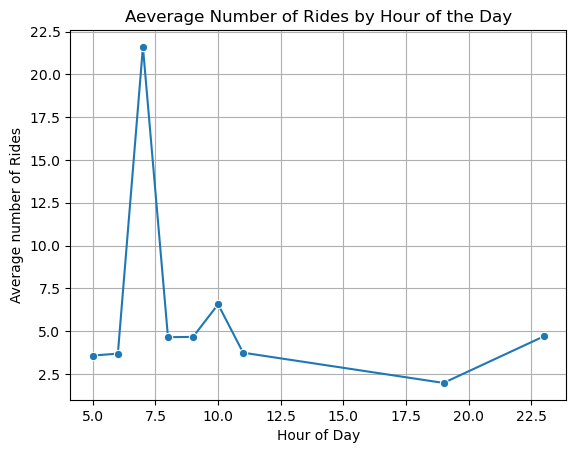

In [242]:
# Line plot showing average number of rides made in each hour of the day

sns.lineplot(data=average_rides_per_hour, x='hours', y='ride_count', marker='o')
plt.title('Aeverage Number of Rides by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average number of Rides')
plt.grid(True)
plt.show()

##### From the analysis, we observe that most departures are made around 7 AM. approximately having 21 ride made in that hour of the day
###### Considering that travel takes approximately 8–9 hours to Kawangware and an additional 2–3 hours to reach Nairobi CBD,
###### these rides are likely to arrive during the evening rush hours, 
###### which could contribute to traffic congestion as multiple vehicles converge at the same time.

In [244]:
# rides made within days
rides_per_days=dt.groupby(['travel_date','day_name'])['ride_id'].count()

rides_per_days

travel_date  day_name 
2017-01-12   Thursday     59
2017-02-12   Sunday       19
2017-03-12   Sunday       28
2017-04-12   Wednesday    45
2017-05-12   Friday       55
                          ..
2018-11-04   Sunday       52
2018-12-01   Saturday     37
2018-12-02   Sunday       59
2018-12-03   Monday       48
2018-12-04   Tuesday      51
Name: ride_id, Length: 149, dtype: int64

In [245]:
# Average rides made in differents days of the week

average_rides_per_day=rides_per_days.groupby('day_name').mean().reset_index(name='ride_count').sort_values('ride_count',ascending=False)
average_rides_per_day

,day_name,ride_count
0,Friday,47.052632
4,Thursday,44.761905
6,Wednesday,44.590909
1,Monday,44.578947
5,Tuesday,40.416667
2,Saturday,38.500000
3,Sunday,34.750000


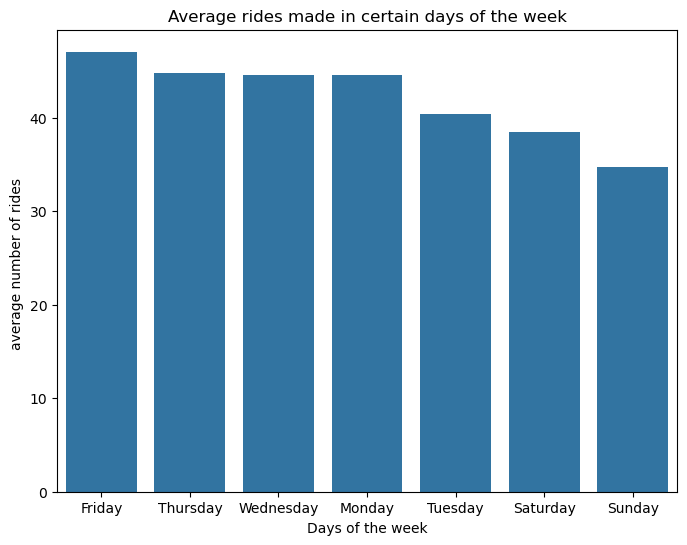

In [246]:
# Average rides made in certain days of the week
plt.figure(figsize=(8,6))
plt.title("Average rides made in certain days of the week")
sns.barplot(data=average_rides_per_day, x='day_name',y='ride_count')
plt.xlabel("Days of the week")
plt.ylabel("average number of rides ")
plt.show()

From the analysis, we observe that Fridays have the highest number of rides, likely due to people traveling
to Nairobi in preparation for the weekend. Other weekdays show relatively similar ride counts, with Tuesday slightly lower than the rest
. On weekends, the data shows the lowest ride activity, reflecting reduced travel demand.
The high number of rides on Fridays could contribute to increased traffic congestion as more vehicles arrive in Nairobi simultaneously.

In [248]:
# rides per month, considering holidays
rides_per_months = dt.groupby(['travel_date','month_name','is_holiday'])['ride_id'].count().reset_index(name='rides_count')

#  average rides per month
average_rides_per_month = rides_per_months.groupby('month_name').agg({
    'rides_count': 'mean',           # average rides
    'is_holiday': 'max'              # if any day in the month is a holiday, this will be 1/True
}).reset_index().rename(columns={'rides_count': 'ride_count', 'is_holiday':'has_holiday'})

#  Sort by average rides descending
# average_rides_per_month = average_rides_per_month.sort_values('ride_count', ascending=False)

average_rides_per_month


,month_name,ride_count,has_holiday
0,April,46.076923,Yes
1,August,50.200000,No
2,December,43.625000,Yes
3,February,46.857143,No
4,January,37.291667,Yes
5,July,50.400000,No
6,June,45.000000,Yes
7,March,35.500000,Yes
8,May,42.000000,Yes
9,November,34.500000,Yes


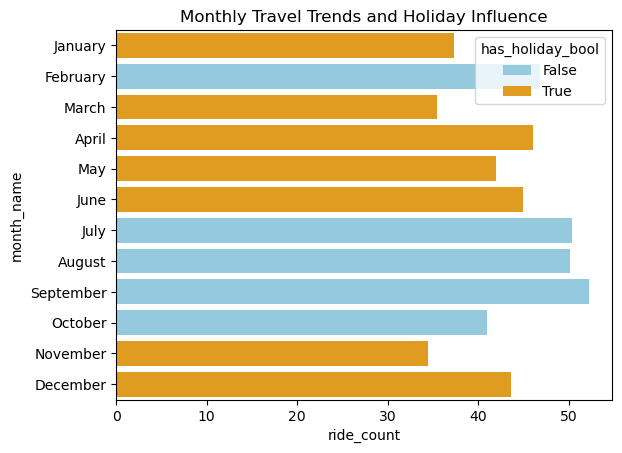

In [249]:

average_rides_per_month['has_holiday_bool'] = average_rides_per_month['has_holiday'].map({'Yes': True, 'No': False})

plt.title("Monthly Travel Trends and Holiday Influence")
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
# Now use Seaborn with hue
sns.barplot(
    data=average_rides_per_month,
    x='ride_count',
    y='month_name',
    hue='has_holiday_bool',
    dodge=False,
    palette={True: 'orange', False: 'skyblue'},
    order=month_order
    
)
plt.show()

From the dataset, we can see that holidays also influence travel patterns
. During holidays, fewer people travel to Nairobi compared to non-holiday periods
. This is likely because many passengers prefer to travel to the countryside or other destinations during holidays rather than going to the city.

#### Geographical Demand

In [252]:

peak_hours = [6,7,8,16,17,18,19,20]
peak_data = dt[dt['hours'].isin(peak_hours)]
peak_data=peak_data.groupby(['travel_from','car_type'])['ride_id'].count().reset_index(name='travel_count').sort_values('travel_count',ascending=False)
peak_data.reset_index(drop=True,inplace=True)
peak_data



,travel_from,car_type,travel_count
0,Kisii,shuttle,1093
1,Rongo,Bus,719
2,Kisii,Bus,519
3,Migori,Bus,386
4,Homa Bay,Bus,356
5,Kijauri,shuttle,208
6,Nyachenge,Bus,194
7,Sirare,Bus,190
8,Awendo,Bus,185
9,Kehancha,Bus,172


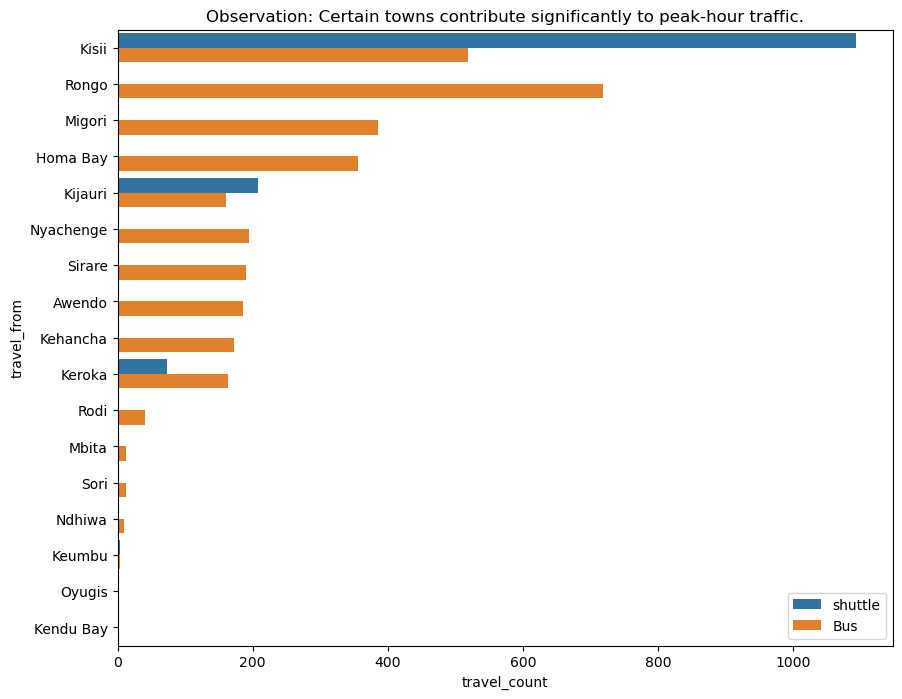

In [253]:
plt.figure(figsize=(10,8))
plt.title('Observation: Certain towns contribute significantly to peak-hour traffic.')
sns.barplot(data=peak_data,x='travel_count',y='travel_from',hue='car_type')
plt.legend(loc='lower right')

From the analysis, we can see that a significant number of rides occur during peak hours. Notably, rides originating from Kisii contribute heavily to the number of arrivals during these times. By plotting the towns of origin for peak-hour rides, we can clearly identify which locations generate the most traffic and observe the distribution of car types serving these routes.

### Vechile Utilization

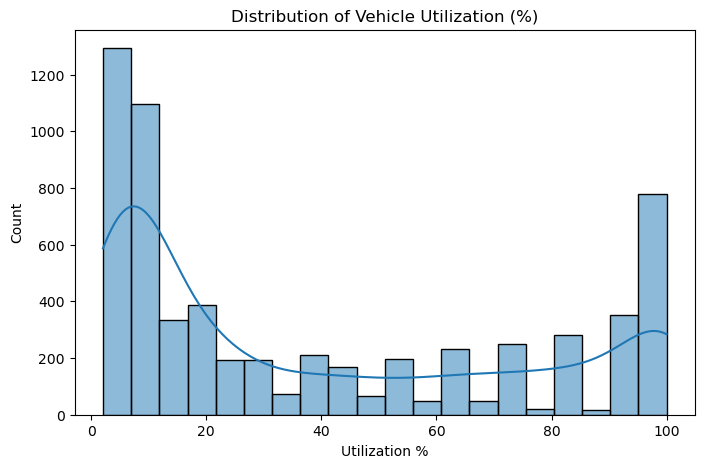

In [256]:
dt['utilization'] = dt['Number_of_tickets'] / dt['max_capacity'] * 100

plt.figure(figsize=(8,5))
sns.histplot(dt['utilization'], bins=20, kde=True)
plt.title("Distribution of Vehicle Utilization (%)")
plt.xlabel("Utilization %")
plt.show()

The analysis reveals the distribution of vehicle utilization across rides. Most rides operate with a utilization below 10%, indicating many vehicles run with minimal occupancy. There are relatively few rides with utilization rates between 10% and 90%, suggesting underutilization across mid-range capacities. However, we observe a noticeable number of rides at 100% utilization, though still fewer compared to those with less than 10% utilization.

###  tickets made within days

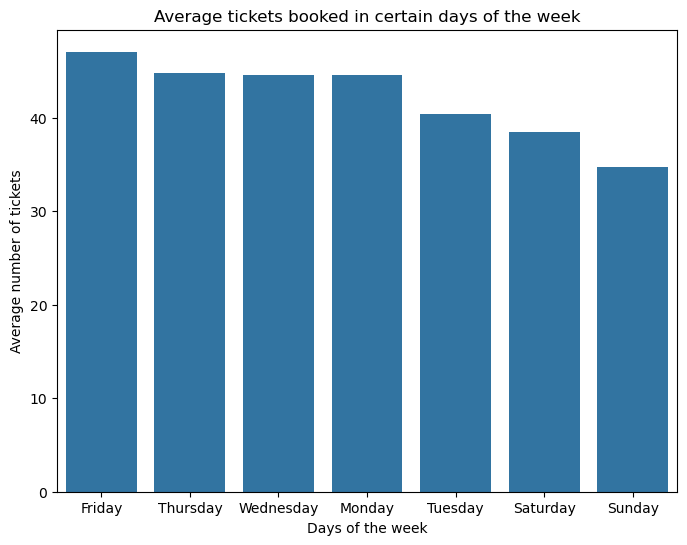

In [510]:
# tickets made within days
tickets_per_days = dt.groupby(['travel_date','day_name'])['Number_of_tickets'].count()
tickets_per_days

# Average tickets made in different days of the week
average_tickets_per_day = tickets_per_days.groupby('day_name').mean().reset_index(name='ticket_count').sort_values('ticket_count', ascending=False)
average_tickets_per_day

plt.figure(figsize=(8,6))
plt.title("Average tickets booked in certain days of the week")
sns.barplot(data=average_tickets_per_day, x='day_name', y='ticket_count')
plt.xlabel("Days of the week")
plt.ylabel("Average number of tickets")
plt.show()

## Feaure Engineering/Model Building

In [259]:
df8.columns

Index(['ride_id', 'travel_date', 'travel_time', 'travel_from', 'travel_to',
       'car_type', 'max_capacity', 'Number_of_tickets', 'Years', 'Months',
       'day_of_week', 'hours', 'minutes', 'is_holiday'],
      dtype='object')

We will prepare the dataset to predict the number of seats booked per ride using features such as travel_from, travel_to, car_type, max_capacity, hours, minutes, dayofweek, month, and year. The target variable will be number_of_tickets. This prediction will support efficient resource allocation, optimal scheduling, and help identify travel times that minimize congestion, ultimately contributing to reducing traffic jams in Nairobi.

In [261]:
df8.head(5)

,ride_id,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,Number_of_tickets,Years,Months,day_of_week,hours,minutes,is_holiday
0,1442,2017-10-17,1900-01-01 07:15:00,Migori,Nairobi,Bus,49,1,2017,10,2,7,15,No
1,5437,2017-11-19,1900-01-01 07:12:00,Migori,Nairobi,Bus,49,1,2017,11,7,7,12,No
2,5710,2017-11-26,1900-01-01 07:05:00,Keroka,Nairobi,Bus,49,1,2017,11,7,7,5,No
3,5777,2017-11-27,1900-01-01 07:10:00,Homa Bay,Nairobi,Bus,49,5,2017,11,1,7,10,No
4,5778,2017-11-27,1900-01-01 07:12:00,Migori,Nairobi,Bus,49,31,2017,11,1,7,12,No


In [262]:
# Dropping non-predictive identifiers  to focus on relevant features for modeling
df9=df8.copy()

df9=df9.drop(['ride_id', 'travel_date','travel_time'],axis=1)
df9.head(5)

,travel_from,travel_to,car_type,max_capacity,Number_of_tickets,Years,Months,day_of_week,hours,minutes,is_holiday
0,Migori,Nairobi,Bus,49,1,2017,10,2,7,15,No
1,Migori,Nairobi,Bus,49,1,2017,11,7,7,12,No
2,Keroka,Nairobi,Bus,49,1,2017,11,7,7,5,No
3,Homa Bay,Nairobi,Bus,49,5,2017,11,1,7,10,No
4,Migori,Nairobi,Bus,49,31,2017,11,1,7,12,No


In [263]:
# Splitting features (X) and target (y) to prepare data for model training

X=df9.drop('Number_of_tickets',axis=1)
y=df9['Number_of_tickets']

In [264]:
# Splitting data into training and testing sets to train the model and evaluate its performance

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [265]:
X_train.shape

(4988, 10)

In [266]:
X_test.shape

(1248, 10)

### Feature Preprocessing

In [268]:
X_train.columns

Index(['travel_from', 'travel_to', 'car_type', 'max_capacity', 'Years',
       'Months', 'day_of_week', 'hours', 'minutes', 'is_holiday'],
      dtype='object')

In [269]:
# Encoding categorical features using OneHotEncoder to convert them into numeric format for model compatibility
categorical_Features = ['travel_from', 'travel_to', 'car_type', 'is_holiday']

ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
X_train_Categorical_encoded = ohe.fit_transform(X_train[categorical_Features])
X_test_Categorical_encoded = ohe.transform(X_test[categorical_Features])


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [270]:
X_train_Categorical_encoded.shape

(4988, 17)

In [271]:
#Encoding the numerical feature

numeric_features=['max_capacity','Years']

scaler=StandardScaler()
X_train_numerics_encoded=scaler.fit_transform(X_train[numeric_features])
X_test_numerics_encoded=scaler.transform(X_test[numeric_features])
X_test_numerics_encoded.shape
joblib.dump(scaler,'numeric_scaler')

['numeric_scaler']

In [272]:
# Encoding cyclical datetime features (hours, minutes, day_of_week, month) using sine and cosine transformations 
# to preserve temporal patterns for the model
def encode_datetime_Xtrain(Xtrain):
    # Encode month (1–12 → /12)
    X_train_months_sin = np.sin(2 * np.pi * Xtrain['Months'] / 12)
    X_train_months_cos = np.cos(2 * np.pi * Xtrain['Months'] / 12)
    
       # Encode day of week (0–6 → /7)
    X_train_days_sin = np.sin(2 * np.pi * Xtrain['day_of_week'] / 7)
    X_train_days_cos = np.cos(2 * np.pi * Xtrain['day_of_week'] / 7)
    
    
    # Encode hours (0–23 → /24)
    X_train_hours_sin = np.sin(2 * np.pi * Xtrain['hours'] / 24)
    X_train_hours_cos = np.cos(2 * np.pi * Xtrain['hours'] / 24)

    # Encode minutes (0–59 → /60)
    X_train_minutes_sin = np.sin(2 * np.pi * Xtrain['minutes'] / 60)
    X_train_minutes_cos = np.cos(2 * np.pi * Xtrain['minutes'] / 60)

 

    

    # Combine all encoded features into one array
    X_train_encoded_datetime = np.column_stack([
        X_train_months_sin, X_train_months_cos,
        X_train_days_sin, X_train_days_cos,
        X_train_hours_sin, X_train_hours_cos,
        X_train_minutes_sin, X_train_minutes_cos
        
        
    ])

    return X_train_encoded_datetime


In [273]:
import numpy as np

def encode_datetime_Xtest(Xtest):
        # Encode month (1–12 → /12)
    X_test_months_sin = np.sin(2 * np.pi * Xtest['Months'] / 12)
    X_test_months_cos = np.cos(2 * np.pi * Xtest['Months'] / 12)

    # Encode day of week (0–6 → /7)
    X_test_days_sin = np.sin(2 * np.pi * Xtest['day_of_week'] / 7)
    X_test_days_cos = np.cos(2 * np.pi * Xtest['day_of_week'] / 7)
    
    # Encode hours (0–23 → /24)
    X_test_hours_sin = np.sin(2 * np.pi * Xtest['hours'] / 24)
    X_test_hours_cos = np.cos(2 * np.pi * Xtest['hours'] / 24)

    # Encode minutes (0–59 → /60)
    X_test_minutes_sin = np.sin(2 * np.pi * Xtest['minutes'] / 60)
    X_test_minutes_cos = np.cos(2 * np.pi * Xtest['minutes'] / 60)

    



    # Stack into one array
    X_test_encoded_datetime = np.column_stack([
        X_test_months_sin, X_test_months_cos,
        X_test_days_sin, X_test_days_cos,
        X_test_hours_sin, X_test_hours_cos,
        X_test_minutes_sin, X_test_minutes_cos
        
    ])

    return X_test_encoded_datetime


In [274]:
# Encoding cyclical datetime features for both training and testing sets 
# to preserve temporal patterns and maintain consistency

X_train_datetime_encoded = encode_datetime_Xtrain(X_train)
X_test_datetime_encoded  = encode_datetime_Xtest(X_test)

print(X_train_datetime_encoded.shape, X_test_datetime_encoded.shape)



(4988, 8) (1248, 8)


In [275]:
#Concatenate the Train data and the test 

X_train_encoded=np.concatenate([X_train_Categorical_encoded,X_train_numerics_encoded,X_train_datetime_encoded],axis=1)
X_test_encoded=np.concatenate([X_test_Categorical_encoded,X_test_numerics_encoded,X_test_datetime_encoded],axis=1)

In [276]:
X_train_encoded.shape

(4988, 27)

In [277]:
print(f"X Train shape:{X_train_encoded.shape}")
print(f"X Test shape:{X_test_encoded.shape}")

X Train shape:(4988, 27)
X Test shape:(1248, 27)


####  Generating columns feature names 

In [279]:
# Retrieving names of encoded categorical features from OneHotEncoder for labeling the final dataset
ohe_feature_names = ohe.get_feature_names_out(categorical_Features)
ohe_feature_names



array(['travel_from_Homa Bay', 'travel_from_Kehancha',
       'travel_from_Keroka', 'travel_from_Keumbu', 'travel_from_Kijauri',
       'travel_from_Kisii', 'travel_from_Mbita', 'travel_from_Migori',
       'travel_from_Ndhiwa', 'travel_from_Nyachenge',
       'travel_from_Oyugis', 'travel_from_Rodi', 'travel_from_Rongo',
       'travel_from_Sirare', 'travel_from_Sori', 'car_type_shuttle',
       'is_holiday_Yes'], dtype=object)

In [280]:
# Defining numeric and encoded datetime feature names for proper labeling of the final dataset
numeric_feature = ['max_capacity', 'Years']
datetime_feature_names = [
    'month_sin', 'month_cos',
    'day_sin', 'day_cos',
    'hour_sin', 'hour_cos',
    'minute_sin', 'minute_cos',
    
]


In [281]:
# Combining encoded categorical, numeric, and datetime feature names 
# to match the columns in the final encoded training dataset
feature_names = list(ohe_feature_names) \
                + numeric_feature \
                + datetime_feature_names 

len(feature_names), X_train_encoded.shape


(27, (4988, 27))

In [282]:
feature_names

['travel_from_Homa Bay',
 'travel_from_Kehancha',
 'travel_from_Keroka',
 'travel_from_Keumbu',
 'travel_from_Kijauri',
 'travel_from_Kisii',
 'travel_from_Mbita',
 'travel_from_Migori',
 'travel_from_Ndhiwa',
 'travel_from_Nyachenge',
 'travel_from_Oyugis',
 'travel_from_Rodi',
 'travel_from_Rongo',
 'travel_from_Sirare',
 'travel_from_Sori',
 'car_type_shuttle',
 'is_holiday_Yes',
 'max_capacity',
 'Years',
 'month_sin',
 'month_cos',
 'day_sin',
 'day_cos',
 'hour_sin',
 'hour_cos',
 'minute_sin',
 'minute_cos']

In [283]:
pd.set_option('display.max_columns',None)

In [284]:
# Convert the columns array of encoded features into a dataframe

X_train_encoded_df=pd.DataFrame(X_train_encoded,columns=feature_names)
X_train_encoded_df.head()

,travel_from_Homa Bay,travel_from_Kehancha,travel_from_Keroka,travel_from_Keumbu,travel_from_Kijauri,travel_from_Kisii,travel_from_Mbita,travel_from_Migori,travel_from_Ndhiwa,travel_from_Nyachenge,travel_from_Oyugis,travel_from_Rodi,travel_from_Rongo,travel_from_Sirare,travel_from_Sori,car_type_shuttle,is_holiday_Yes,max_capacity,Years,month_sin,month_cos,day_sin,day_cos,hour_sin,hour_cos,minute_sin,minute_cos
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.978185,-1.673001,-2.449294e-16,1.000000e+00,4.338837e-01,-0.900969,0.965926,-0.258819,0.406737,9.135455e-01
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.978185,0.597728,-2.449294e-16,1.000000e+00,-2.449294e-16,1.000000,0.965926,-0.258819,1.000000,2.832769e-16
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.978185,0.597728,1.000000e+00,6.123234e-17,-7.818315e-01,0.623490,0.965926,-0.258819,0.500000,8.660254e-01
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.978185,0.597728,1.000000e+00,6.123234e-17,-7.818315e-01,0.623490,0.965926,-0.258819,0.913545,4.067366e-01
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.022302,-1.673001,-8.660254e-01,5.000000e-01,-4.338837e-01,-0.900969,0.258819,-0.965926,0.809017,5.877853e-01


## Model Building

In [286]:
# Training a Linear Regression model to learn relationships between features and the target variable

lr = LinearRegression()
lr.fit(X_train_encoded, y_train)


LinearRegression()

In [287]:
# Making predictions on the test set using the trained Linear Regression model
y_pred = lr.predict(X_test_encoded)


In [288]:
# Evaluating model performance using Mean Absolute Error (MAE) and R² score 
# to measure prediction accuracy and goodness of fit
mae = mean_absolute_error(y_test, y_pred)
r2score = r2_score(y_test, y_pred)

print(f"MAE: {mae}, R² Score: {r2score}")


MAE: 4.827236077724359, R² Score: 0.3831998961355144


In [289]:
# Hyperparameter tuning for XGBoost using RandomizedSearchCV to find the best model configuration
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# Base model
model = XGBRegressor(random_state=42)

# Hyperparameter search space
param_dist = {
    'max_depth': [5, 10, 15, 20, 30, 40, 50],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [50, 80, 100, 120]
}

# Randomized Search for optimal parameters
rand_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,  
    n_iter=20,                       # tries 20 random combinations
    cv=3,                            
    scoring='neg_mean_absolute_error', 
    random_state=42,
    n_jobs=-1                        # parallel processing for speed
)

# Fit search to training data
rand_search.fit(X_train_encoded, y_train)
best_model = rand_search


In [290]:
# Extracting the best XGBoost model from the randomized search and saving it for future use
best_model_XGB_randsearch = rand_search.best_estimator_

joblib.dump(best_model_XGB_randsearch, 'XGB_model')


['XGB_model']

In [291]:
# Getting feature importance scores from the best XGBoost model 
# and creating a sorted DataFrame to identify the most influential features
importance = best_model_XGB_randsearch .feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

feature_importance_df


,Feature,Importance
0,travel_from_Homa Bay,0.232206
1,travel_from_Sirare,0.182645
2,travel_from_Migori,0.118870
3,travel_from_Kijauri,0.069969
4,hour_sin,0.044807
5,travel_from_Nyachenge,0.043804
6,travel_from_Keroka,0.038363
7,minute_sin,0.034794
8,minute_cos,0.029746
9,travel_from_Mbita,0.029180


#### “Our model shows route (location) is the key driver of ticket sales, indicating demand is 
#### primarily determined by where trips start. Time of day also influences bookings (peak vs. off-peak), 
#### but month, year, and holiday effects are minor. This means we should optimize scheduling around high-demand routes
#### and peak hours rather than focusing on seasonal campaigns.”

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8852\2757375700.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")


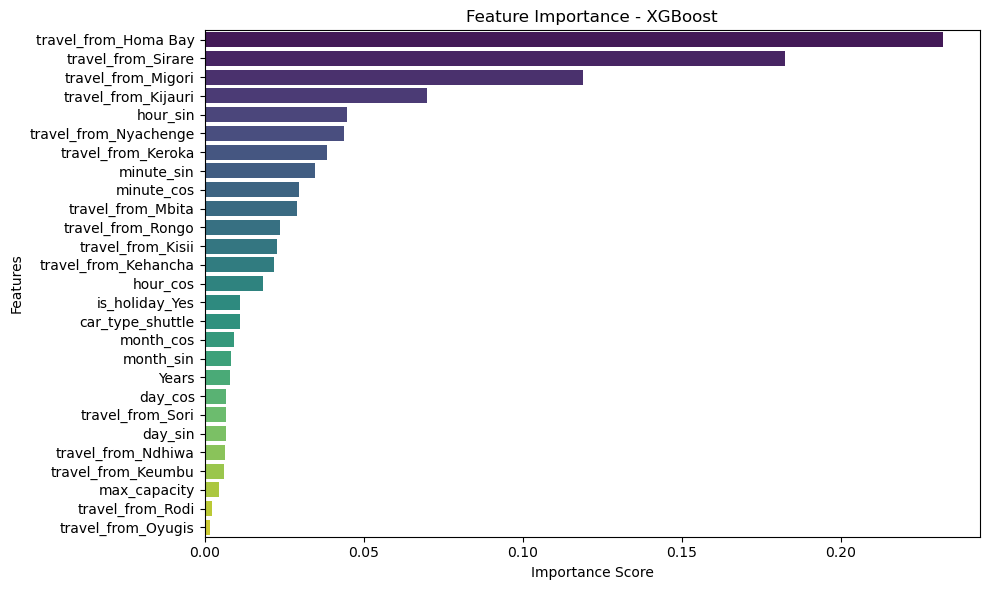

In [293]:
# Visualizing feature importances using Seaborn for a cleaner and more informative plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [303]:
# Displaying the best hyperparameters found by RandomizedSearchCV
print("Best Params:", rand_search.best_params_)

Best Params: {'subsample': 0.8, 'n_estimators': 120, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [309]:
# Making predictions on the test set using the best XGBoost model from RandomizedSearchCV
y_predXGB = best_model_XGB_randsearch.predict(X_test_encoded)


In [311]:
# Evaluating the tuned XGBoost model on the test set using MAE and R² score
XGBmae = mean_absolute_error(y_test, y_predXGB)
XGBr2score = r2_score(y_test, y_predXGB)

print(f"MAE: {XGBmae:.4f}, R²: {XGBr2score:.4f}")


MAE: 3.8593, R²: 0.5813



The model achieved an MAE of ~3.9 and an R² of 0.58, meaning it explains just over half of booking variation. If we add more detailed features,  the model could capture hidden patterns and improve prediction accuracy.

## Random ForestRegressor

In [318]:
# Training a Random Forest Regressor without hyperparameter tuning
# to provide a baseline model for comparison
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train_encoded, y_train)

# Make predictions on the test set
RF_y_pred = rf_model.predict(X_test_encoded)


In [320]:
# Evaluating the baseline Random Forest model using MAE and R² score
RFmae = mean_absolute_error(y_test, RF_y_pred)
RFr2score = r2_score(y_test, RF_y_pred)

print(f"MAE: {RFmae:.4f}, R²: {RFr2score:.4f}")

MAE: 3.8984, R²: 0.5336


The baseline Random Forest model achieved an MAE of 3.90 and an R² of 0.53, showing a slight decrease in performance compared to the tuned XGBoost model, but an improvement over the Linear Regression model. This indicates that even without tuning, Random Forest captures nonlinear patterns better than Linear Regression, though XGBoost with hyperparameter optimization still provides the most accurate predictions.

In [323]:
# Hyperparameter tuning for Random Forest Regressor using GridSearchCV 
# to find the best combination of parameters for improved performance
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Base model
model = RandomForestRegressor(random_state=42)

# Parameter grid for tuning
params = {
    "n_estimators": [50, 80, 100, 120, 150],
    "max_depth": [5, 10, 15, 20, 25],
    "min_samples_split": [2, 5, 10, 15],
    "max_features": ['sqrt', 'log2', 0.5]
}

# Initialize GridSearchCV
gridcv = GridSearchCV(
    estimator=model,
    param_grid=params,
    n_jobs=-1,                     # parallel processing
    cv=3,                         
    scoring='neg_mean_absolute_error' #
)

# Fit GridSearch to training data
gridcv.fit(X_train_encoded, y_train)


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, 20, 25],
                         'max_features': ['sqrt', 'log2', 0.5],
                         'min_samples_split': [2, 5, 10, 15],
                         'n_estimators': [50, 80, 100, 120, 150]},
             scoring='neg_mean_absolute_error')

I found that the model performed well without bootstrapping, but this risks overfitting on our small dataset. Using bootstrap=True trains each tree on random samples, helping reduce overfitting and improve generalization.

In [330]:
# Extracting the best Random Forest model from GridSearchCV and saving it for future use
best_rf_model = gridcv.best_estimator_

print("Best params are:", gridcv.best_params_)




Best params are: {'max_depth': 20, 'max_features': 0.5, 'min_samples_split': 15, 'n_estimators': 80}


In [342]:
#Feature importance

important_features=best_rf_model.feature_importances_

df_important_features=pd.DataFrame({
    "Feature_name":feature_names,
    "importance":important_features
}).sort_values(by="importance",ascending=False).reset_index(drop=True)


top10features=df_important_features.head(10)
top10features

,Feature_name,importance
0,minute_sin,0.138048
1,travel_from_Migori,0.125073
2,travel_from_Homa Bay,0.120888
3,minute_cos,0.116748
4,travel_from_Sirare,0.115611
5,hour_sin,0.054842
6,month_cos,0.048077
7,month_sin,0.041291
8,hour_cos,0.038418
9,travel_from_Kijauri,0.036580


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8852\2712882237.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Feature_name", y="importance", data=top10features, palette="viridis")


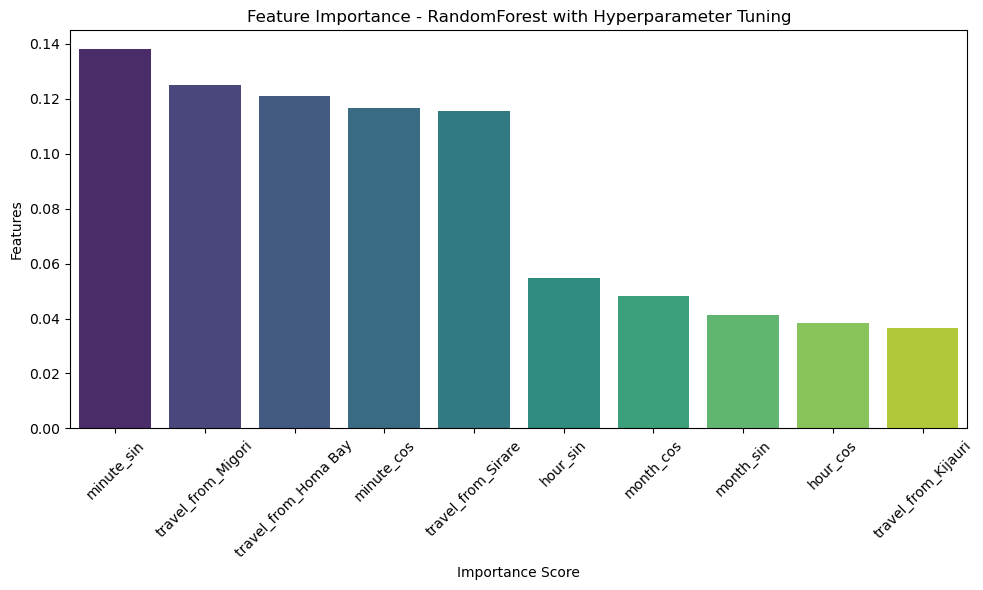

In [356]:
# Visualizing feature importances using Seaborn for a cleaner and more informative plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x="Feature_name", y="importance", data=top10features, palette="viridis")
plt.title("Feature Importance - RandomForest with Hyperparameter Tuning")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [358]:
# Making predictions with the tuned Random Forest model and evaluating performance
y_pred_tunedrf = best_rf_model.predict(X_test_encoded)

tunedrf_mae = mean_absolute_error(y_test, y_pred_tunedrf)
tunedrf_r2score = r2_score(y_test, y_pred_tunedrf)

print(f"MAE: {tunedrf_mae:.4f}, R²: {tunedrf_r2score:.4f}")


MAE: 3.7028, R²: 0.6099


The tuned Random Forest achieved an MAE of 3.70 and an R² of 0.61, showing an improvement over the baseline Random Forest and Linear Regression models. This indicates that hyperparameter tuning helped the model better capture patterns in the data, reducing prediction error and explaining more variation in ticket bookings.

#### Saving model and encoders


In [332]:
# Save the tuned model
joblib.dump(best_rf_model, 'RFgridsearch_model')

['RFgridsearch_model']

In [365]:
joblib.dump(ohe,'OnehotEncoder')


['OnehotEncoder']

In [367]:
joblib.dump(scaler,'scaler_encoder')

['scaler_encoder']

# Predicing the test dataset

In [421]:
# Load the dataset

testdata=pd.read_csv(r"C:\Users\ADMIN\Desktop\unzipped\PROJECTS\Traffic Jam_ Predicting People_s Movement into Nairobi\Traffic Jam Predicting People_s Movement into Nairobi\Traffic Jam Predicting People's Movement into Nairobi\test_questions.csv")

In [423]:
testdata.shape

(1111, 7)

In [425]:
testdata.head()

,ride_id,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,247,2018-05-07,07:06,Kisii,Nairobi,Bus,49
1,256,2018-05-06,11:08,Kisii,Nairobi,shuttle,11
2,275,2018-05-04,05:00,Kisii,Nairobi,shuttle,11
3,285,2018-05-04,09:10,Kisii,Nairobi,shuttle,11
4,286,2018-05-04,09:20,Kisii,Nairobi,shuttle,11


In [427]:
test=testdata.copy()

In [429]:
# spliting the time   feature to hours and nites
test['travel_time']=pd.to_datetime(test['travel_time'],format='%H:%M')
test['travel_date']=pd.to_datetime(test['travel_date'])

In [431]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1111 entries, 0 to 1110
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ride_id       1111 non-null   int64         
 1   travel_date   1111 non-null   datetime64[ns]
 2   travel_time   1111 non-null   datetime64[ns]
 3   travel_from   1111 non-null   object        
 4   travel_to     1111 non-null   object        
 5   car_type      1111 non-null   object        
 6   max_capacity  1111 non-null   int64         
dtypes: datetime64[ns](2), int64(2), object(3)
memory usage: 60.9+ KB


In [433]:
test['hours']=test['travel_time'].dt.hour
test['minutes']=test['travel_time'].dt.minute
test['day_of_week']=test['travel_date'].dt.dayofweek+1
test['Months']=test['travel_date'].dt.month
test['Years']=test['travel_date'].dt.year


In [435]:
test.head(5)

,ride_id,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,hours,minutes,day_of_week,Months,Years
0,247,2018-05-07,1900-01-01 07:06:00,Kisii,Nairobi,Bus,49,7,6,1,5,2018
1,256,2018-05-06,1900-01-01 11:08:00,Kisii,Nairobi,shuttle,11,11,8,7,5,2018
2,275,2018-05-04,1900-01-01 05:00:00,Kisii,Nairobi,shuttle,11,5,0,5,5,2018
3,285,2018-05-04,1900-01-01 09:10:00,Kisii,Nairobi,shuttle,11,9,10,5,5,2018
4,286,2018-05-04,1900-01-01 09:20:00,Kisii,Nairobi,shuttle,11,9,20,5,5,2018


In [439]:


# Create 'is_holiday' column with 'Yes' or 'No' values
test['is_holiday'] = test['travel_date'].isin(ke_holidays).map({True: 'Yes', False: 'No'})

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8852\2620700072.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  test['is_holiday'] = test['travel_date'].isin(ke_holidays).map({True: 'Yes', False: 'No'})


In [441]:
test.head(5)

,ride_id,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,hours,minutes,day_of_week,Months,Years,is_holiday
0,247,2018-05-07,1900-01-01 07:06:00,Kisii,Nairobi,Bus,49,7,6,1,5,2018,No
1,256,2018-05-06,1900-01-01 11:08:00,Kisii,Nairobi,shuttle,11,11,8,7,5,2018,No
2,275,2018-05-04,1900-01-01 05:00:00,Kisii,Nairobi,shuttle,11,5,0,5,5,2018,No
3,285,2018-05-04,1900-01-01 09:10:00,Kisii,Nairobi,shuttle,11,9,10,5,5,2018,No
4,286,2018-05-04,1900-01-01 09:20:00,Kisii,Nairobi,shuttle,11,9,20,5,5,2018,No


In [443]:
test.shape

(1111, 13)

In [447]:
len(test[test['is_holiday']=='Yes'])

108

In [449]:
test.columns

Index(['ride_id', 'travel_date', 'travel_time', 'travel_from', 'travel_to',
       'car_type', 'max_capacity', 'hours', 'minutes', 'day_of_week', 'Months',
       'Years', 'is_holiday'],
      dtype='object')

In [451]:
# drop the columns that were not fitted in our model
test1=test.copy()

test1=test1.drop(['ride_id', 'travel_date', 'travel_time'],axis=1)

In [453]:
test1.columns

Index(['travel_from', 'travel_to', 'car_type', 'max_capacity', 'hours',
       'minutes', 'day_of_week', 'Months', 'Years', 'is_holiday'],
      dtype='object')

In [455]:
# encode our columns

In [457]:
# export the saved encoder

scaler1=joblib.load('scaler_encoder')
ohe1=joblib.load('OnehotEncoder')


In [459]:
# encode all the catecorical features

categorical_features=['travel_from', 'travel_to', 'car_type','is_holiday']

test_category_encoded=ohe1.transform(test1[categorical_features])
test_categorical_feature_name=ohe1.get_feature_names_out(categorical_features)
test_categorical_feature_name

array(['travel_from_Homa Bay', 'travel_from_Kehancha',
       'travel_from_Keroka', 'travel_from_Keumbu', 'travel_from_Kijauri',
       'travel_from_Kisii', 'travel_from_Mbita', 'travel_from_Migori',
       'travel_from_Ndhiwa', 'travel_from_Nyachenge',
       'travel_from_Oyugis', 'travel_from_Rodi', 'travel_from_Rongo',
       'travel_from_Sirare', 'travel_from_Sori', 'car_type_shuttle',
       'is_holiday_Yes'], dtype=object)

In [461]:
#Numerical Feautures

numeric=['max_capacity','Years']
numerics_encoded=scaler.transform(test1[numeric])
numerics_encoded
numeric_feature_names=['max_capacity','Years']

In [463]:
def encode_datetime_test(test_data):

    # Encode month (1–12 → /12)
    test_months_sin = np.sin(2 * np.pi * test_data['Months'] / 12)
    test_months_cos = np.cos(2 * np.pi * test_data['Months'] / 12)

    # Encode day of week (0–6 → /7)
    test_days_sin = np.sin(2 * np.pi * test_data['day_of_week'] / 7)
    test_days_cos = np.cos(2 * np.pi * test_data['day_of_week'] / 7)

    # Encode hours (0–23 → /24)
    test_hours_sin = np.sin(2 * np.pi * test_data['hours'] / 24)
    test_hours_cos = np.cos(2 * np.pi * test_data['hours'] / 24)

    # Encode minutes (0–59 → /60)
    test_minutes_sin = np.sin(2 * np.pi * test_data['minutes'] / 60)
    test_minutes_cos = np.cos(2 * np.pi * test_data['minutes'] / 60)

    
    

    # Stack everything into one array
    test_datetime = np.column_stack([
        test_months_sin, test_months_cos,
        X_train_days_sin, test_days_cos,
        test_hours_sin, test_hours_cos,
        test_minutes_sin, test_minutes_cos,
        
    ])

    return test_datetime

In [465]:
test_datetime_encoded = encode_datetime_Xtrain(test1)
datetime_feature_names = [
    'month_sin', 'month_cos',
    'day_sin', 'day_cos',
    'hour_sin', 'hour_cos',
    'minute_sin', 'minute_cos',
    
    
]


In [467]:
feature_names=list(test_categorical_feature_name) \
            + numeric_feature_names \
            + datetime_feature_names \
            

In [469]:
feature_names

['travel_from_Homa Bay',
 'travel_from_Kehancha',
 'travel_from_Keroka',
 'travel_from_Keumbu',
 'travel_from_Kijauri',
 'travel_from_Kisii',
 'travel_from_Mbita',
 'travel_from_Migori',
 'travel_from_Ndhiwa',
 'travel_from_Nyachenge',
 'travel_from_Oyugis',
 'travel_from_Rodi',
 'travel_from_Rongo',
 'travel_from_Sirare',
 'travel_from_Sori',
 'car_type_shuttle',
 'is_holiday_Yes',
 'max_capacity',
 'Years',
 'month_sin',
 'month_cos',
 'day_sin',
 'day_cos',
 'hour_sin',
 'hour_cos',
 'minute_sin',
 'minute_cos']

In [471]:
testdataencoded=np.concatenate([test_category_encoded,numerics_encoded,test_datetime_encoded],axis=1)

In [473]:
testdata_df=pd.DataFrame(testdataencoded,columns=feature_names)

In [475]:
testdata_df.head()

,travel_from_Homa Bay,travel_from_Kehancha,travel_from_Keroka,travel_from_Keumbu,travel_from_Kijauri,travel_from_Kisii,travel_from_Mbita,travel_from_Migori,travel_from_Ndhiwa,travel_from_Nyachenge,travel_from_Oyugis,travel_from_Rodi,travel_from_Rongo,travel_from_Sirare,travel_from_Sori,car_type_shuttle,is_holiday_Yes,max_capacity,Years,month_sin,month_cos,day_sin,day_cos,hour_sin,hour_cos,minute_sin,minute_cos
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.978185,0.597728,0.5,-0.866025,7.818315e-01,0.623490,0.965926,-0.258819,0.587785,0.809017
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.022302,0.597728,0.5,-0.866025,-2.449294e-16,1.000000,0.258819,-0.965926,0.743145,0.669131
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.022302,0.597728,0.5,-0.866025,-9.749279e-01,-0.222521,0.965926,0.258819,0.000000,1.000000
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.022302,0.597728,0.5,-0.866025,-9.749279e-01,-0.222521,0.707107,-0.707107,0.866025,0.500000
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.022302,0.597728,0.5,-0.866025,-9.749279e-01,-0.222521,0.707107,-0.707107,0.866025,-0.500000


In [477]:
#load model for predicting
model=joblib.load("RFgridsearch_model")

In [479]:
predicted_no_tickets=model.predict(testdataencoded)
predicted_no_tickets = np.round(predicted_no_tickets).astype(int)

In [481]:
predicted_no_tickets

array([ 9,  7,  2, ...,  5, 10, 20])

In [485]:
testdata['predicted_no_tickets']=predicted_no_tickets

In [487]:
testdata.head()

,ride_id,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,predicted_no_tickets
0,247,2018-05-07,07:06,Kisii,Nairobi,Bus,49,9
1,256,2018-05-06,11:08,Kisii,Nairobi,shuttle,11,7
2,275,2018-05-04,05:00,Kisii,Nairobi,shuttle,11,2
3,285,2018-05-04,09:10,Kisii,Nairobi,shuttle,11,8
4,286,2018-05-04,09:20,Kisii,Nairobi,shuttle,11,9


In [ ]:
#save to excel 
testdf.to_excel(r"C:\Users\ADMIN\Desktop\unzipped\PROJECTS\Traffic Jam_ Predicting People_s Movement into Nairobi\Traffic Jam Predicting People_s Movement into Nairobi\Traffic Jam Predicting People's Movement into Nairobi\newly_predicted_tickets.xlsx", index=False)